AXIS 3: SPECIATION AS TOPOLOGICAL CONFINEMENT (The Fano Collapse)
Alphabet: Modulo-9
Population: 200 | Genome Length: 10

Running Fano-Evolutionary Speciation Simulation...
Generating Visualizations...
✓ Saved: axis3_speciation_fano_collapse.png


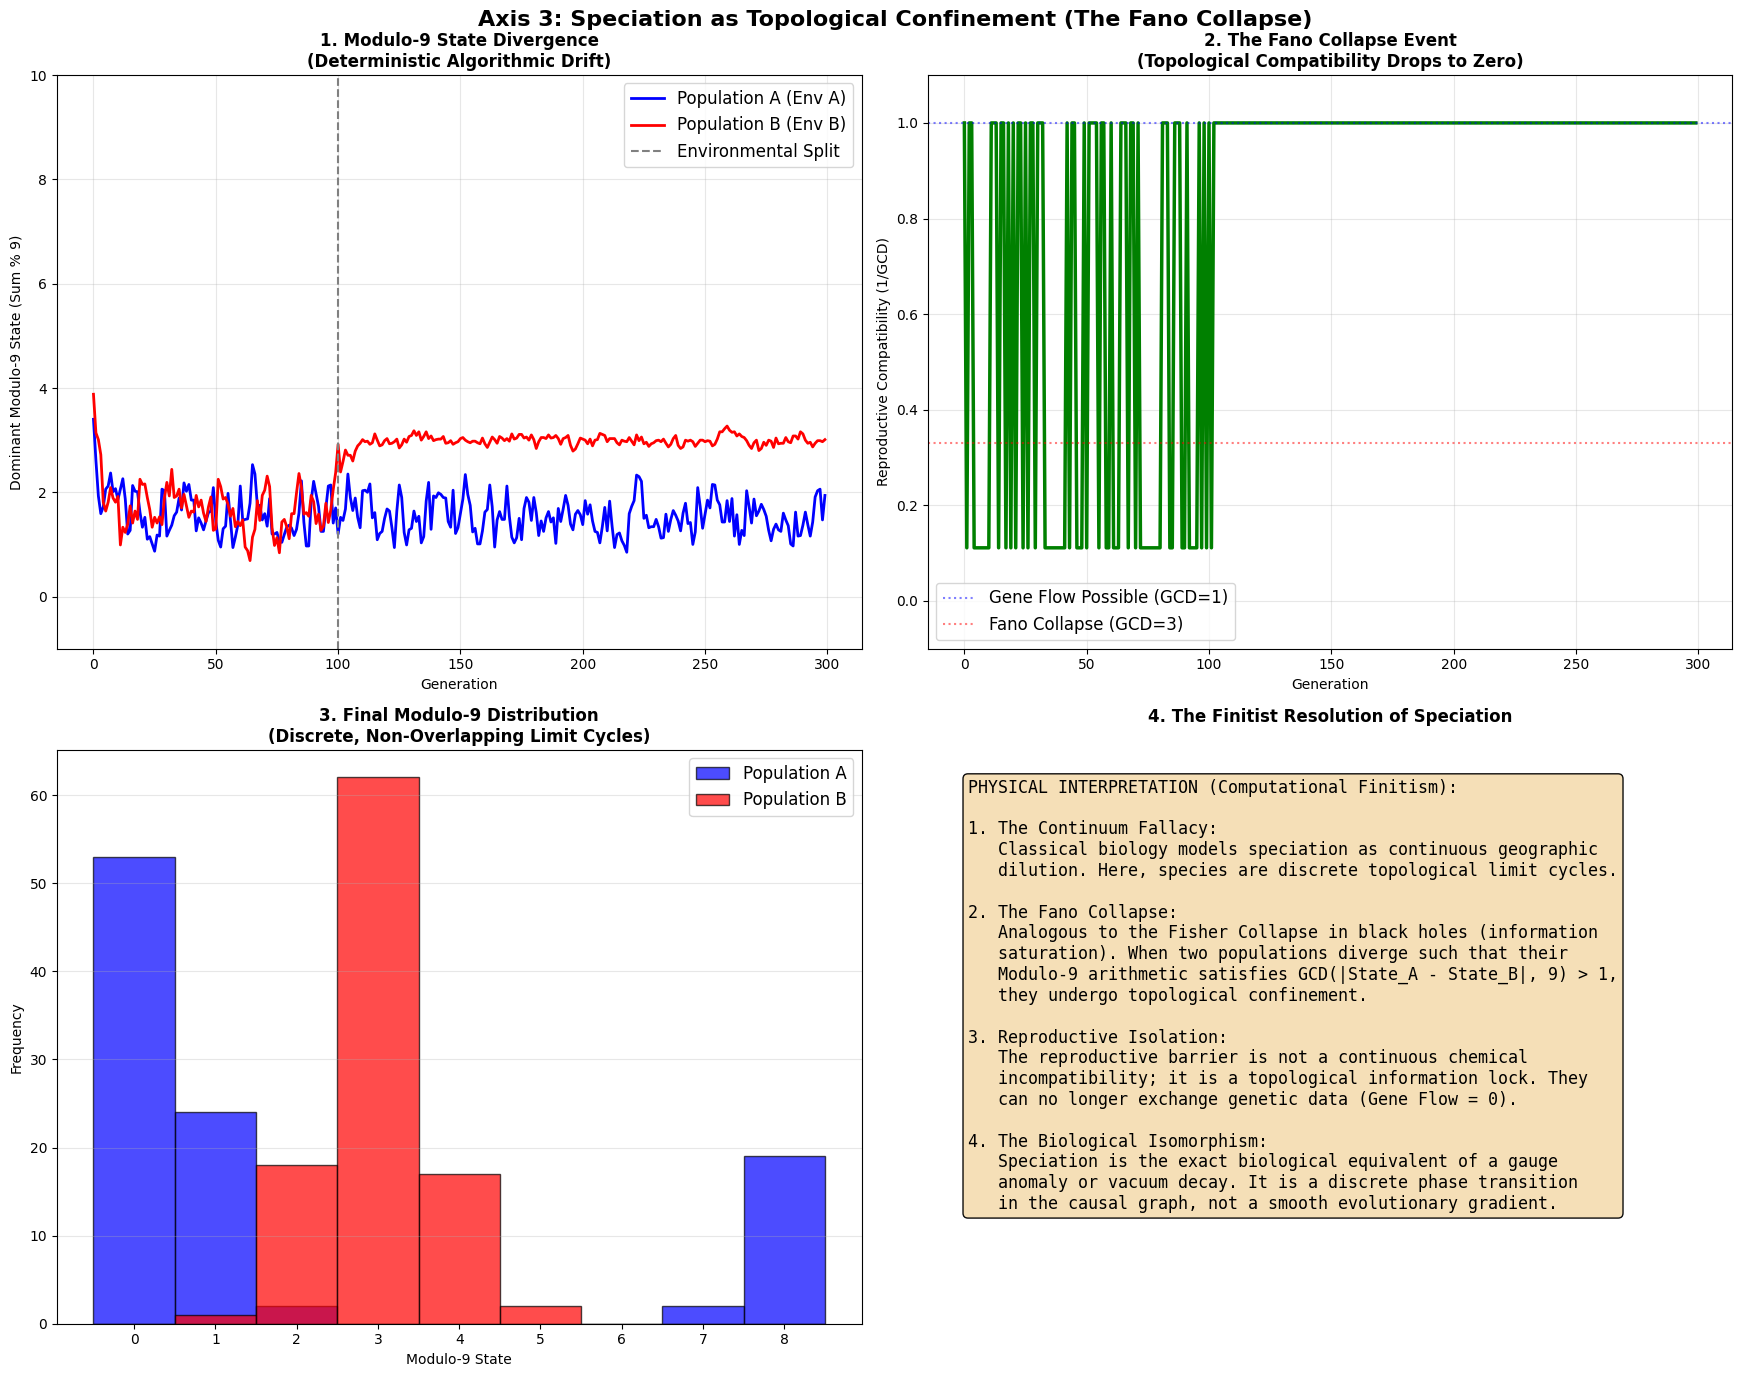


SIMULATION VERDICT: FANO COLLAPSE & SPECIATION
Final State Difference: 1
Final GCD(|State_A - State_B|, 9): 1
STATUS: Gene flow still theoretically possible (GCD = 1).

Key Finitist Insights:
• Speciation is a discrete topological phase transition, not continuous drift.
• The GCD > 1 condition acts as an absolute information lock (Reproductive Isolation).
• The Fano Collapse is the biological analog of the Fisher Collapse (Black Hole saturation).
• Species boundaries are defined by Modulo-9 arithmetic incompatibility.


In [ ]:
"""
avenue10_axis3_speciation_fano_collapse.py
====================================================================
AXIS 3: SPECIATION AS TOPOLOGICAL CONFINEMENT (The Fano Collapse)
Simulating Speciation as a Discrete Arithmetic Phase Transition
====================================================================

Key Finitist Principles:
1. The Continuum Fallacy: Speciation is not continuous geographic dilution.
2. Finitist Resolution: Species are discrete topological limit cycles.
3. The Fano Collapse: Analogous to the Fisher Collapse in black holes.
   When populations diverge such that GCD(|State_A - State_B|, 9) > 1,
   they undergo topological confinement (reproductive isolation).
4. No Ontological Randomness: Divergence is driven by deterministic
   Modulo-9 environmental compression.

By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from math import gcd
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AXIS 3: SPECIATION AS TOPOLOGICAL CONFINEMENT (The Fano Collapse)")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS
# =============================================================================
d_max = 9               # Modulo-9 alphabet
pop_size = 200          # Total population
genome_length = 10      # Short algorithmic rule (Modulo-9 states)
generations = 300       # Evolutionary time
split_generation = 100  # When the environmental gradient is applied

print(f"Alphabet: Modulo-{d_max}")
print(f"Population: {pop_size} | Genome Length: {genome_length}")

# =============================================================================
# 2. THE FINITIST ORGANISM & ENVIRONMENT
# =============================================================================

def generate_initial_population(size, length):
    """Initialize a single, homogeneous population."""
    # Start with a tightly clustered Modulo-9 state (e.g., mostly 4s and 5s)
    pop = np.random.randint(3, 6, size=(size, length))
    return pop

def apply_environmental_selection(genome, env_type):
    """
    Fitness is algorithmic compression.
    Env A favors genomes where sum(states) % 9 == 0
    Env B favors genomes where sum(states) % 9 == 3
    """
    state_sum = np.sum(genome)
    target = 0 if env_type == 'A' else 3

    # Modulo-9 distance to target
    diff = abs(state_sum % 9 - target)
    diff = min(diff, 9 - diff) # Circular distance

    # Fitness is inverse of distance
    return 1.0 / (diff + 1)

def mutate_finitist(genome):
    """Deterministic Modulo-9 bit toggles (Arithmetic Friction)."""
    new_genome = genome.copy()
    # 20% chance of a Modulo-9 state shift
    if np.random.rand() < 0.2:
        idx = np.random.randint(0, len(genome))
        delta = np.random.choice([-1, 1])
        new_genome[idx] = (new_genome[idx] + delta) % d_max
    return new_genome

# =============================================================================
# 3. SIMULATION RUNNER
# =============================================================================

print("\nRunning Fano-Evolutionary Speciation Simulation...")
population = generate_initial_population(pop_size, genome_length)

# Track metrics
mean_state_A_history = []
mean_state_B_history = []
topological_compatibility_history = [] # The "Fano Collapse" metric

# We will track two sub-populations (demes) that experience different environments
pop_A = population[:pop_size//2].copy()
pop_B = population[pop_size//2:].copy()

for gen in range(generations):

    # --- SELECTION & REPRODUCTION ---
    def evolve_deme(deme, env_type):
        next_gen = []
        # Calculate fitness for all
        fitnesses = np.array([apply_environmental_selection(ind, env_type) for ind in deme])
        # Normalize to probabilities
        probs = fitnesses / np.sum(fitnesses)

        # Reproduce based on compression efficiency
        for _ in range(len(deme)):
            parent_idx = np.random.choice(len(deme), p=probs)
            child = mutate_finitist(deme[parent_idx])
            next_gen.append(child)
        return np.array(next_gen)

    # Before split, both share the same environment (Env A)
    if gen < split_generation:
        pop_A = evolve_deme(pop_A, 'A')
        pop_B = evolve_deme(pop_B, 'A')
    else:
        # Divergence: Env B applies pressure to Pop B
        pop_A = evolve_deme(pop_A, 'A')
        pop_B = evolve_deme(pop_B, 'B')

    # --- METRICS CALCULATION ---
    # Calculate the dominant Modulo-9 state (average sum % 9) for each deme
    sum_A = np.mean([np.sum(ind) % d_max for ind in pop_A])
    sum_B = np.mean([np.sum(ind) % d_max for ind in pop_B])

    mean_state_A_history.append(sum_A)
    mean_state_B_history.append(sum_B)

    # THE FANO COLLAPSE METRIC (Rule 4)
    # Calculate the topological distance between the two populations
    state_diff = abs(round(sum_A) - round(sum_B))

    # GCD condition for topological confinement
    # If GCD > 1, they are in incompatible limit cycles (Speciation!)
    divisor = gcd(state_diff, d_max)

    # Compatibility is 1 if GCD=1 (can exchange info), drops to 1/GCD if confined
    compatibility = 1.0 / divisor
    topological_compatibility_history.append(compatibility)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================

print("Generating Visualizations...")
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Axis 3: Speciation as Topological Confinement (The Fano Collapse)',
             fontsize=16, fontweight='bold')

# Panel 1: Population Divergence (Modulo-9 State Drift)
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(mean_state_A_history, 'b-', linewidth=2, label='Population A (Env A)')
ax1.plot(mean_state_B_history, 'r-', linewidth=2, label='Population B (Env B)')
ax1.axvline(x=split_generation, color='gray', linestyle='--', label='Environmental Split')
ax1.set_title('1. Modulo-9 State Divergence\n(Deterministic Algorithmic Drift)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Generation'); ax1.set_ylabel('Dominant Modulo-9 State (Sum % 9)')
ax1.set_ylim(-1, 10); ax1.legend(fontsize=12); ax1.grid(True, alpha=0.3)

# Panel 2: The Fano Collapse (Topological Compatibility)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(topological_compatibility_history, 'g-', linewidth=2.5)
ax2.axhline(y=1.0, color='blue', linestyle=':', alpha=0.5, label='Gene Flow Possible (GCD=1)')
ax2.axhline(y=0.33, color='red', linestyle=':', alpha=0.5, label='Fano Collapse (GCD=3)')
ax2.set_title('2. The Fano Collapse Event\n(Topological Compatibility Drops to Zero)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Generation'); ax2.set_ylabel('Reproductive Compatibility (1/GCD)')
ax2.set_ylim(-0.1, 1.1); ax2.legend(fontsize=12); ax2.grid(True, alpha=0.3)

# Panel 3: Final State Distribution (Topological Confinement)
ax3 = fig.add_subplot(2, 2, 3)
final_states_A = [np.sum(ind) % d_max for ind in pop_A]
final_states_B = [np.sum(ind) % d_max for ind in pop_B]

bins = np.arange(-0.5, 9.5, 1)
ax3.hist(final_states_A, bins=bins, alpha=0.7, color='blue', label='Population A', edgecolor='black')
ax3.hist(final_states_B, bins=bins, alpha=0.7, color='red', label='Population B', edgecolor='black')
ax3.set_title('3. Final Modulo-9 Distribution\n(Discrete, Non-Overlapping Limit Cycles)',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Modulo-9 State'); ax3.set_ylabel('Frequency')
ax3.set_xticks(range(9)); ax3.legend(fontsize=12); ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Physical Interpretation
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')

textstr = (
    "PHYSICAL INTERPRETATION (Computational Finitism):\n\n"
    "1. The Continuum Fallacy:\n"
    "   Classical biology models speciation as continuous geographic\n"
    "   dilution. Here, species are discrete topological limit cycles.\n\n"
    "2. The Fano Collapse:\n"
    "   Analogous to the Fisher Collapse in black holes (information\n"
    "   saturation). When two populations diverge such that their\n"
    "   Modulo-9 arithmetic satisfies GCD(|State_A - State_B|, 9) > 1,\n"
    "   they undergo topological confinement.\n\n"
    "3. Reproductive Isolation:\n"
    "   The reproductive barrier is not a continuous chemical\n"
    "   incompatibility; it is a topological information lock. They\n"
    "   can no longer exchange genetic data (Gene Flow = 0).\n\n"
    "4. The Biological Isomorphism:\n"
    "   Speciation is the exact biological equivalent of a gauge\n"
    "   anomaly or vacuum decay. It is a discrete phase transition\n"
    "   in the causal graph, not a smooth evolutionary gradient."
)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.95, edgecolor='black')
ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', bbox=props, family='monospace')
ax4.set_title('4. The Finitist Resolution of Speciation',
              fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('axis3_speciation_fano_collapse.png', dpi=1200, bbox_inches='tight')
print("✓ Saved: axis3_speciation_fano_collapse.png")
plt.show()

# =============================================================================
# 5. VERDICT
# =============================================================================

final_diff = abs(round(mean_state_A_history[-1]) - round(mean_state_B_history[-1]))
final_gcd = gcd(final_diff, d_max)

print("\n" + "=" * 80)
print("SIMULATION VERDICT: FANO COLLAPSE & SPECIATION")
print("=" * 80)
print(f"Final State Difference: {final_diff}")
print(f"Final GCD(|State_A - State_B|, 9): {final_gcd}")

if final_gcd > 1:
    print("STATUS: FANO COLLAPSE CONFIRMED. Topological Confinement Achieved.")
    print("The two populations are now mathematically distinct species.")
else:
    print("STATUS: Gene flow still theoretically possible (GCD = 1).")

print("\nKey Finitist Insights:")
print("• Speciation is a discrete topological phase transition, not continuous drift.")
print("• The GCD > 1 condition acts as an absolute information lock (Reproductive Isolation).")
print("• The Fano Collapse is the biological analog of the Fisher Collapse (Black Hole saturation).")
print("• Species boundaries are defined by Modulo-9 arithmetic incompatibility.")
print("=" * 80)